# Forecasting `Ziekteverzuimpercentage` — Seasonal Baseline vs (S)ARIMA(X)

## The Basics: ARIMA($p, d, q$)

A standard ARIMA model tries to predict the future purely by looking at the **past of the time series itself**. It consists of three core components:

### 1. AR: Autoregressive ($p$)

* **What it does:** This part looks at the relationship between the current value and a certain number of past values (lags).
* **Intuition:** If it rained yesterday and the day before, there is a good chance it will rain today too. The parameter $p$ specifies how many steps back in time we look.

### 2. I: Integrated ($d$)

* **What it does:** This stands for *differencing*. It subtracts yesterday's value from today's value to make the time series **stationary**.
* **Intuition:** ARIMA does not perform well if there is a clear upward or downward trend in your data (non-stationary). By taking the differences between consecutive days, you remove the trend, leaving a more stable baseline. The parameter $d$ indicates how many times you need to perform this differencing (usually 1 or 2 times).

### 3. MA: Moving Average ($q$)

* **What it does:** This component looks at the forecast errors (residuals) that the model made in the past.
* **Intuition:** If there was an unexpected "shock" in the market yesterday (for example, a sudden power outage that caused sales to drop), the MA component helps capture this shock and its lingering effects. The parameter $q$ determines how many of these historical errors are factored in.

---

## The Upgrades: S & X

Now that we have the foundation, we can introduce external factors and seasonal patterns.

### S: Seasonal ($(P, D, Q)_s$)

As soon as you deal with patterns that repeat at fixed intervals—such as higher ice cream sales in the summer, or lower website traffic on weekends—you add the **S** for *Seasonal*.

* The SARIMA notation expands to include an extra set of parameters: $SARIMA(p,d,q)(P,D,Q)_s$.
* The lowercase $s$ represents the length of the season (e.g., $s=12$ for monthly data with an annual pattern, or $s=7$ for daily data with a weekly pattern).
* The uppercase $P, D, Q$ perform the exact same functions as their lowercase counterparts, but specifically for seasonal steps (for example, comparing *this* July to *last* July).

### X: Exogenous variables (Regressors)

Up until now, the model only looked at its own history. But what if you know that an external factor has a massive influence? For example:

* Predicting electricity consumption, where the **outdoor temperature** plays a huge role.
* Predicting sales revenue, where your **marketing budget** drives the volume.

These types of external variables are called **exogenous variables** (X). The SARIMAX model combines a traditional linear regression (for the X variables) with the SARIMA model (for the remaining time-series dynamics).

---

## Summary of Components

| Component | Meaning | Parameter | What does it measure? |
| --- | --- | --- | --- |
| **AR** | Autoregressive | $p$ | The effect of preceding time steps. |
| **I** | Integrated | $d$ | Number of transformations needed to remove trends (stationarity). |
| **MA** | Moving Average | $q$ | The effect of unexpected shocks/errors from the past. |
| **S** | Seasonal | $P, D, Q, s$ | Repeating patterns at fixed intervals (e.g., seasons or weekly cycles). |
| **X** | Exogenous | *N/A* | External influences (e.g., weather conditions or advertising costs). |

## **Box-Jenkins methodology**.

---

## Phase 1: Prepare and Explore your Data

### Step 1: Plot the Time Series

*`This was already done during EDA. We know from 80072NED that there is a clear trend up and seasonality in the absenteeism data`*

### Step 2: Check for Stationarity (The "I" component)

ARIMA assumes that the data is **stationary**, meaning its mean, variance, and autocorrelation don't change over time. If the data has a trend or seasonality, we must remove it.

* **The Visual Test:** Does the mean look constant, or is it climbing/falling? *`--> DONE DURING EDA. CLEAR TREND UPWARDS.`*
* **The Statistical Test:** Run the **Augmented Dickey-Fuller (ADF) test** (available in `statsmodels`).
* If the $p$-value is **$< 0.05$**, your data is stationary. You can set $d = 0$.
* If the $p$-value is **$\ge 0.05$**, your data is non-stationary.


* **Action:** If it's non-stationary, apply differencing (`df.diff().dropna()`) and rerun the ADF test. Keep track of how many times you difference to make it stationary; this number is your **$d$** parameter (usually $1$ or $2$).

#### Get data and prep

In [104]:
import sqlite3
import pandas as pd

# 1. Check what tables are in the silver_data.db database
conn = sqlite3.connect('../../data/2_silver/silver_data.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in database:", cursor.fetchall())

# 2. Load the 80072NED table from the silver_data.db database. 
# Only select columns 'Perioden' and 'Ziekteverzuimpercentage_1'.
# Filter on column 'BedrijfskenmerkenSBI2008' value T001081
# and on column 'Perioden' values containing 'KW' only.
query = '''
    SELECT "Perioden", "Ziekteverzuimpercentage_1" 
    FROM "80072ned_silver" 
    WHERE "BedrijfskenmerkenSBI2008" = "T001081" 
      AND "Perioden" LIKE "%KW%"
'''
df = pd.read_sql_query(query, conn)
df['Ziekteverzuimpercentage_1'] = pd.to_numeric(df['Ziekteverzuimpercentage_1'], errors='coerce')

# 3. Check df info
print("\n--- Dataframe Info ---")
print(df.info())

# 4. Check for missing values in the 'Ziekteverzuimpercentage_1' column
print(f"\Missing values in 'Ziekteverzuimpercentage_1': {df['Ziekteverzuimpercentage_1'].isnull().sum()}")

# 5. Clean 'Perioden' column and convert to first day of the quarter
df = df[~df['Perioden'].str.contains('JJ00')].copy()
df['Perioden'] = pd.PeriodIndex(df['Perioden'].str.replace('KW0', 'Q'), freq='Q').to_timestamp()

# 6. Set the 'Perioden' column as the index and sort the index
df.set_index('Perioden', inplace=True)
df.sort_index(inplace=True)

# 7. Filter data from 2006 onwards due to calculation methodology change
# This removes the structural break from the historical data
df_from2006 = df['2006':]

print("\n--- Head of filtered data (2006 onwards) ---")
print(df_from2006.head(10))

# Close the database connection safely
conn.close()

Tables in database: [('80590eng_silver',), ('80072ned_silver',), ('85916NED_silver',), ('85917NED_silver',), ('85920NED_silver',)]

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Perioden                   120 non-null    object 
 1   Ziekteverzuimpercentage_1  120 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.0+ KB
None
\Missing values in 'Ziekteverzuimpercentage_1': 0

--- Head of filtered data (2006 onwards) ---
            Ziekteverzuimpercentage_1
Perioden                             
2006-01-01                        4.6
2006-04-01                        4.0
2006-07-01                        3.7
2006-10-01                        4.3
2007-01-01                        4.6
2007-04-01                        4.0
2007-07-01                        3.7
2007-10-01            

#### Check data set for seasonality and stationarity

##### Automatic seasonality detection

In [105]:
import numpy as np
import pandas as pd
from scipy.signal import periodogram

def detect_seasonal_period(series):
    # Remove trend to prevent frequency 0 from dominating
    detrended = series.diff().dropna()
    
    # Compute the periodogram
    frequencies, power = periodogram(detrended)
    
    # Skip the first element (frequency 0 / DC component)
    frequencies = frequencies[1:]
    power = power[1:]
    
    # Find the frequency with the maximum power
    dominant_idx = np.argmax(power)
    dominant_frequency = frequencies[dominant_idx]
    
    # Calculate the period (1 / frequency)
    # Round to the nearest integer since periods are discrete lags
    estimated_period = int(np.round(1 / dominant_frequency))
    
    print(f"--- SEASONALITY DETECTION ---")
    print(f"Dominant frequency found: {dominant_frequency:.4f}")
    print(f"Estimated seasonal period: {estimated_period}")
    
    # Guardrail: If the estimated period is too high (e.g., half the dataset size) 
    # or equal to 1, there is likely no real seasonality.
    if estimated_period <= 1 or estimated_period > (len(series) / 2):
        print("-> No clear seasonal pattern detected. Defaulting to period=1 (No seasonality).")
        return 1
        
    return estimated_period

##### Remove trends and seasonality

In [106]:
from statsmodels.tsa.stattools import adfuller, acf

def automatic_data_prep(series): # 'period' parameter is removed here!
    series = series.dropna()
    
    print("--- STEP 1: Test raw data via ADF ---")
    p_raw = adfuller(series)[1]
    print(f"p-value of raw data: {p_raw:.4f}")
    
    if p_raw < 0.05:
        print("-> The raw data is already stationary! No differencing needed.")
        return series, 0, 0
    
    # NEW: Automatically detect the period before moving to Step 2
    s = detect_seasonal_period(series)
    
    print("\n--- STEP 2: Automatically determine optimal trend differencing (d) ---")
    # Compute both scenarios (1x diff and 2x diff)
    diff1 = series.diff(1).dropna()
    diff2 = diff1.diff(1).dropna()
    
    # Compute the variance for both scenarios
    var1 = diff1.var()
    var2 = diff2.var()
    
    # Compute the lag-1 autocorrelation of the twice-differenced data
    # This acts as our guardrail against over-differencing
    acf_diff2 = acf(diff2, nlags=1, fft=True)
    lag1_acf_diff2 = acf_diff2[1]
    
    print(f"Variance after 1x diff (d=1): {var1:.4f}")
    print(f"Variance after 2x diff (d=2): {var2:.4f}")
    print(f"Lag-1 autocorrelation of d=2 data: {lag1_acf_diff2:.4f}")
    
    # AUTOMATIC DECISION LOGIC:
    # We only choose d=2 IF the variance decreases AND the lag-1 correlation does not drop below -0.5.
    if var2 < var1 and lag1_acf_diff2 >= -0.5:
        print("-> Decision: d=2. (Variance decreased and no severe over-differencing detected).")
        trend_differenced = diff2
        d = 2
    else:
        if var2 >= var1:
            print("-> Decision: d=1. (Variance did not decrease with a second differentiation).")
        elif lag1_acf_diff2 < -0.5:
            print("-> Decision: d=1. (d=2 would cause over-differencing, lag-1 acf < -0.5).")
        trend_differenced = diff1
        d = 1
    
    # --- STEP 3: Compute seasonal pattern via ACF on detrended data (d={d}) ---
    acf_values = acf(trend_differenced, nlags=s, fft=True)
    bound = 1.96 / np.sqrt(len(trend_differenced))
    correlation_lag_4 = acf_values[s]
    
    has_seasonal_pattern = abs(correlation_lag_4) > bound
    print(f"\n--- STEP 3: Analyze Seasonal Pattern (Period={s}) ---")
    print(f"Autocorrelation at lag {s}: {correlation_lag_4:.4f} (Statistical bound: {bound:.4f})")
    
    D = 0
    if has_seasonal_pattern:
        # Create a test scenario for seasonal differencing
        seasonal_diff_candidate = trend_differenced.diff(s).dropna()
        
        # AUTOMATED CHECK: Does seasonal diff actually improve the data?
        var_before_seas = trend_differenced.var()
        var_after_seas = seasonal_diff_candidate.var()
        
        # Check lag-1 ACF of the candidate to prevent seasonal over-differencing
        lag1_acf_seas = acf(seasonal_diff_candidate, nlags=1, fft=True)[1]
        
        print(f"Variance before seasonal diff: {var_before_seas:.4f}")
        print(f"Variance after seasonal diff: {var_after_seas:.4f}")
        print(f"Lag-1 autocorrelation after seasonal diff: {lag1_acf_seas:.4f}")
        
        if var_after_seas < var_before_seas and lag1_acf_seas >= -0.5:
            print(f"-> Decision: D=1. (Seasonal pattern confirmed by variance reduction).")
            processed_data = seasonal_diff_candidate
            D = 1
        else:
            print(f"-> Decision: D=0. (Skipped seasonal diff: it would introduce too much noise/over-differencing).")
            processed_data = trend_differenced
    else:
        print("-> Decision: D=0. (No significant seasonal pattern detected via ACF).")
        processed_data = trend_differenced

    print("\n--- STEP 4: Check final data stationarity ---")
    if len(processed_data) > 20:
        p_final = adfuller(processed_data)[1]
        print(f"p-value of final data: {p_final:.4f}")
        
        if p_final < 0.05:
            print(f"-> Data is stationary! Suggested SARIMA parameters: (d={d}, D={D})")
        else:
            print(f"-> Note: Data is still not stationary even after processing (d={d}, D={D}).")
    else:
        print("-> Note: Too few observations left to verify final stationarity.")
        
    return processed_data, d, D, s

In [107]:
## Call the automatic_data_prep function
df_diff, d, D, s = automatic_data_prep(df_from2006['Ziekteverzuimpercentage_1'])  # Assuming quarterly data, period=4

--- STEP 1: Test raw data via ADF ---
p-value of raw data: 0.9021
--- SEASONALITY DETECTION ---
Dominant frequency found: 0.2532
Estimated seasonal period: 4

--- STEP 2: Automatically determine optimal trend differencing (d) ---
Variance after 1x diff (d=1): 0.2173
Variance after 2x diff (d=2): 0.4464
Lag-1 autocorrelation of d=2 data: -0.0923
-> Decision: d=1. (Variance did not decrease with a second differentiation).

--- STEP 3: Analyze Seasonal Pattern (Period=4) ---
Autocorrelation at lag 4: 0.7718 (Statistical bound: 0.2205)
Variance before seasonal diff: 0.2173
Variance after seasonal diff: 0.0819
Lag-1 autocorrelation after seasonal diff: -0.2889
-> Decision: D=1. (Seasonal pattern confirmed by variance reduction).

--- STEP 4: Check final data stationarity ---
p-value of final data: 0.0000
-> Data is stationary! Suggested SARIMA parameters: (d=1, D=1)


## Phase 2: Identify the Model Orders ($p$ and $q$)

Once your data is stationary, you need to figure out how many historical steps ($p$) and historical errors ($q$) to include.

### Step 3: Plot ACF and PACF

Generate an **Autocorrelation Function (ACF)** plot and a **Partial Autocorrelation Function (PACF)** plot using your *stationary* data.

* **To find $p$ (AR term):** Look at the **PACF** plot. Look for the lag where the correlation suddenly drops off and enters the blue "insignificant" boundary. If it drops off after lag 2, then $p = 2$.
* **To find $q$ (MA term):** Look at the **ACF** plot. Use the same logic. If the correlation cuts off sharply after lag 1, then $q = 1$.

> **Tip:** If both plots gradually tail off rather than cutting off sharply, you might need a combination of both AR and MA terms. Don't worry if it takes some trial and error!

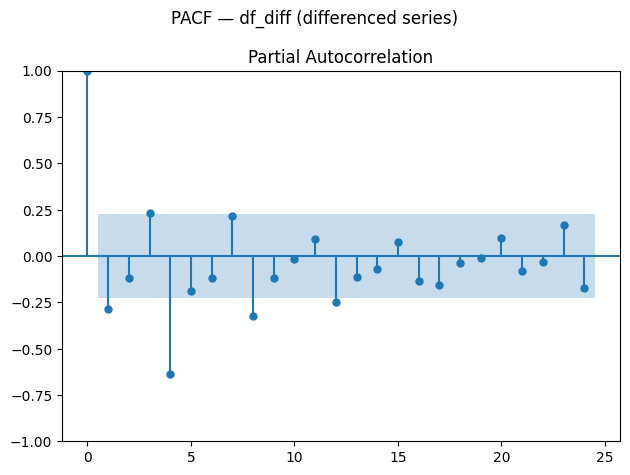

In [108]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt

fig = plot_pacf(df_diff, lags=24, alpha=0.05)
fig.suptitle('PACF — df_diff (differenced series)')
fig.tight_layout()
plt.show()


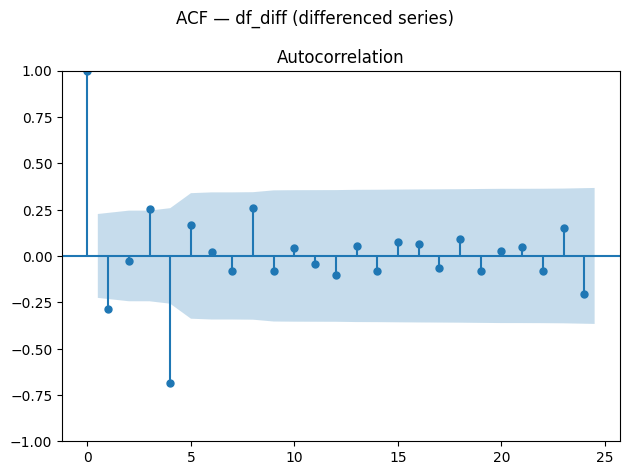

In [109]:

fig_acf = plot_acf(df_diff, lags=24, alpha=0.05)
fig_acf.suptitle('ACF — df_diff (differenced series)')
fig_acf.tight_layout()

##### Conclusion PACF and ACF

**1. The Seasonal Part ($P$ and $Q$) at Lag 4, 8, 12...**

For a period of 4, we first look at the "beacons" at the positions of the multiples of 4.
* ACF: We see a huge, significant negative spike at lag 4 (well past -0.5). Looking further at lag 8, lag 12, and lag 16, we see that the bars fall completely within the blue margin right away. This is a perfect, sharp cutoff after exactly 1 seasonal period.
    * Conclusion: A sharp cutoff in the ACF at the seasonal lag indicates a Seasonal Moving Average (SMA) component. So: $Q = 1$.
* PACF: Here we see a different pattern at the seasonal lags. There is a sizeable spike at lag 4, a smaller negative spike at lag 8, and an even smaller one at lag 12. The seasonal lags are thus slowly dying out (tailing off). This confirms that the seasonal part is an MA process and not an AR process.
    * Conclusion: Because the PACF tails off at the seasonal lags, we don't need any seasonal AR terms. So: $P = 0$.

**2. The Regular Part ($p$ and $q$) and the "Multiplicative Shadow"**

Now that we look at the early lags (1, 2, 3), something strange immediately stands out: why are both lag 1 (negative) and lag 3 (positive) so clearly significant?

This is the ultimate learning tip for SARIMA: this is no coincidence, but the result of a mathematical multiplication (interaction) between the regular part and the seasonal part.

When you combine a regular MA(1) with a seasonal MA(1), these filters multiply each other. In the ACF this produces a very recognizable pattern of "shadow spikes" around the seasonal lag ($s$):
* A spike at lag 1 (the regular MA term itself)
* A spike at lag $s - 1$ (in your case: $4 - 1 = 3$)
* A spike at lag $s$ (the seasonal MA itself at lag 4)
* A spike at lag $s + 1$ (in your case: $4 + 1 = 5$, which in your case does not reach the blue boundary in practice, for a simple mathematical reason). The strength of the spike at lag 5 is, in theory, equal to the regular MA value multiplied by the seasonal MA value ($\theta \times \Theta$).
    * If those two separate values both lie around 0.3 or 0.4, then their product ($0.3 \times 0.4 = 0.12$) is very small.
    * Such a small value is often too weak to rise above the blue noise boundary in a real dataset.

Because we see exactly this signature pattern (spikes at 1, 3, 4, and 5) in your ACF, we know that the regular part is an MA(1) process, and not an AR process. Conclusion: $p = 0$ and $q = 1$.

**Final Conclusion & Model Recommendation**

Based on the generated plots, the perfect candidate model for the dataset is:$$\text{SARIMA}(0, 1, 1) \times (0, 1, 1)_4$$

## Phase 3: Train and Validate


### Step 4: Split your Data (The Golden Rule)

Never use a random train-test split for time series! You cannot use the future to predict the past.

* **Action:** Define the length of the rolling window, for instance 60. Decide if the window shouls shift per quarter or per year.

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. CONFIGURATION & DATA INITIALISATION
# ==========================================
# Make sure the index is a DatetimeIndex with the quarterly frequency set
df = df_from2006.copy()
df.index = pd.to_datetime(df.index)
df = df.resample('QE').last()  # 'QE' enforces the quarterly frequency at the end of the quarter

# Model parameters (p, d, q) x (P, D, Q, s)
ORDER = (0, d, 1)            # Fill in your own p, d, q here
SEASONAL_ORDER = (0, D, 1, 4) # Fill in your own P, D, Q here (s=4 for quarters)

# Set the target column
TARGET_COLUMN = 'Ziekteverzuimpercentage_1'


# ==========================================
# PHASE 3: TRAIN AND VALIDATE
# ==========================================

### STEP 4: Split your Data (The Golden Rule)
# We define the length of our rolling window and the forecast horizon.
WINDOW_SIZE = 48  # 12 years of historical data to train on per step
HORIZON = 4       # Forecast the coming 4 quarters

# Split into CV data and the ultimate hold-out test set (last year / 4 quarters)
cv_data = df.iloc[:-HORIZON]  
final_test_data = df.iloc[-HORIZON:] 

print(f"Total dataset size: {len(df)} quarters")
print(f"Cross-validation pool: {len(cv_data)} quarters")
print(f"Ultimate hold-out test set: {len(final_test_data)} quarters\n")

Total dataset size: 80 quarters
Cross-validation pool: 76 quarters
Ultimate hold-out test set: 4 quarters



### Step 5: Fit the SARIMA Model

Using `statsmodels.tsa.statespace.sarimax`, input your training data and the $(p, d, q)$ parameters you discovered.

In [112]:
### STEP 5: Fit the SARIMA Model (Rolling Window Cross-Validation)
print("--- STEP 5: Start Rolling Window Cross-Validation ---")

all_predictions = []
all_actuals = []

# Loop through the data with a sliding window (shift per quarter)
for i in range(len(cv_data) - WINDOW_SIZE - HORIZON + 1):
    train_start = i
    train_end = i + WINDOW_SIZE
    val_start = train_end
    val_end = val_start + HORIZON
    
    train_set = cv_data.iloc[train_start:train_end]
    val_set = cv_data.iloc[val_start:val_end]
    
    # Fit the model on the temporary training window
    model = SARIMAX(train_set[TARGET_COLUMN], 
                    order=ORDER, 
                    seasonal_order=SEASONAL_ORDER,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    
    # Forecast the horizon
    forecast = model_fit.forecast(steps=HORIZON)
    
    all_predictions.append(forecast.values)
    all_actuals.append(val_set[TARGET_COLUMN].values)

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Show intermediate validation results
print("\n[Validation results] Average RMSE across the rolling windows:")
for step in range(HORIZON):
    rmse_step = root_mean_squared_error(all_actuals[:, step], all_predictions[:, step])
    print(f"  Quarter t+{step+1} ahead: RMSE = {rmse_step:.2f}")

--- STEP 5: Start Rolling Window Cross-Validation ---

[Validation results] Average RMSE across the rolling windows:
  Quarter t+1 ahead: RMSE = 0.28
  Quarter t+2 ahead: RMSE = 0.34
  Quarter t+3 ahead: RMSE = 0.38
  Quarter t+4 ahead: RMSE = 0.43


## Phase 4: Diagnostic Checking and Evaluation

### Step 6: Analyze the Residuals

Your model's leftovers (errors/residuals) should look like **white noise**—meaning they are completely random with no leftover patterns.

* **Action:** Run `model_fit.plot_diagnostics()`.
* **What to check:** In the standardized residuals plot, you want to see a random scatter around zero. In the histogram, the KDE line should closely match the normal distribution line. If you see patterns, your model is missing information.


--- Start Evaluation on the Ultimate Hold-out Set ---

--- STEP 6: Analyze the Residuals ---
Check whether the residuals resemble 'white noise' (random around zero, KDE follows the normal distribution).


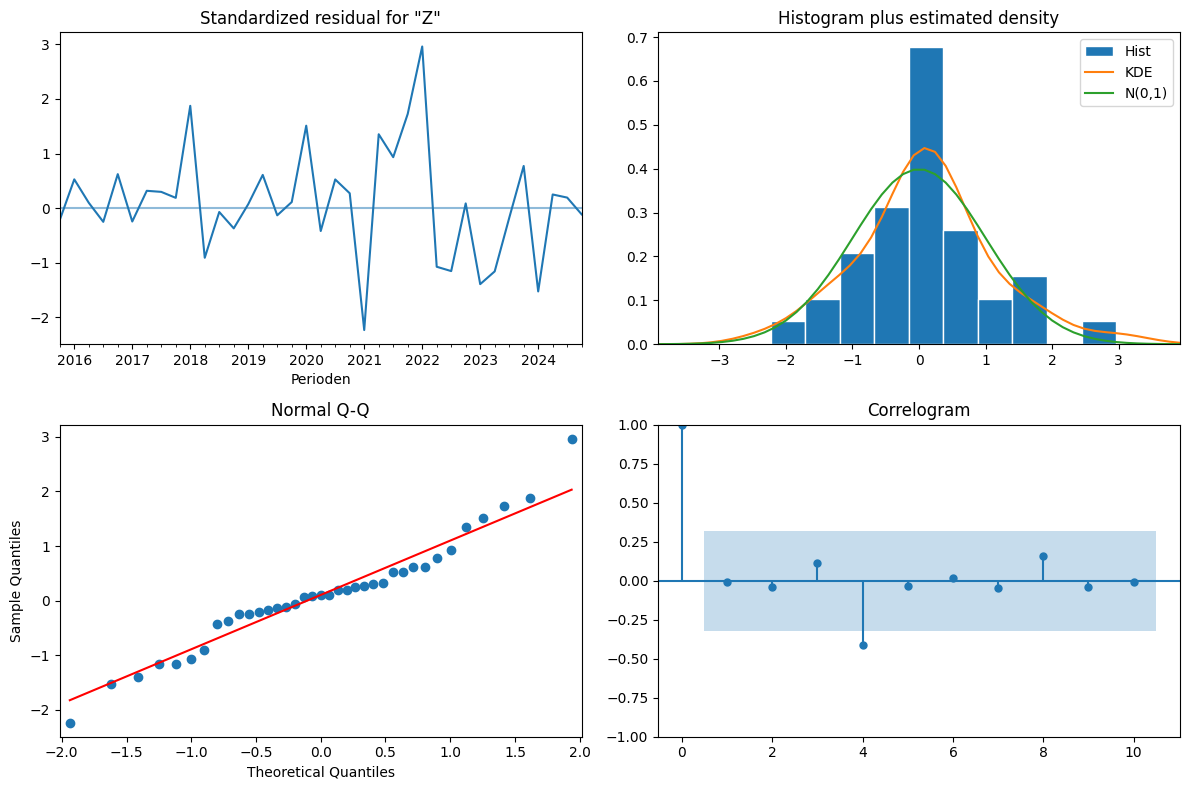

In [113]:
# ==========================================
# PHASE 4: DIAGNOSTIC CHECKING AND EVALUATION
# ==========================================

# We now train the definitive model on the most recent complete window of the cv_data
# in order to test it on the unseen hold-out set.
print("\n--- Start Evaluation on the Ultimate Hold-out Set ---")
final_train_set = cv_data.iloc[-WINDOW_SIZE:]

final_model = SARIMAX(final_train_set[TARGET_COLUMN], 
                      order=ORDER, 
                      seasonal_order=SEASONAL_ORDER,
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)


### STEP 6: Analyze the Residuals
print("\n--- STEP 6: Analyze the Residuals ---")
print("Check whether the residuals resemble 'white noise' (random around zero, KDE follows the normal distribution).")

# Generate the diagnostic plots
final_model_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()


### Step 7: Forecast and Calculate Metrics

Generate predictions for your test set period and compare them to the actual values.

* **Action:** Calculate evaluation metrics like **RMSE** (Root Mean Squared Error) or **MAE** (Mean Absolute Error).
* Plot the training data, the actual test data, and your forecast on a single graph to visually judge how well your model performed.


--- STEP 7: Forecast and Calculate Metrics ---
Final evaluation on the hold-out set (last 4 quarters):
  -> RMSE (Root Mean Squared Error): 0.07
  -> MAE  (Mean Absolute Error):     0.06

Comparison table:
            Actual  Predicted
Perioden                     
2025-03-31     5.8   5.752261
2025-06-30     5.2   5.219030
2025-09-30     5.1   4.994030
2025-12-31     5.6   5.527363


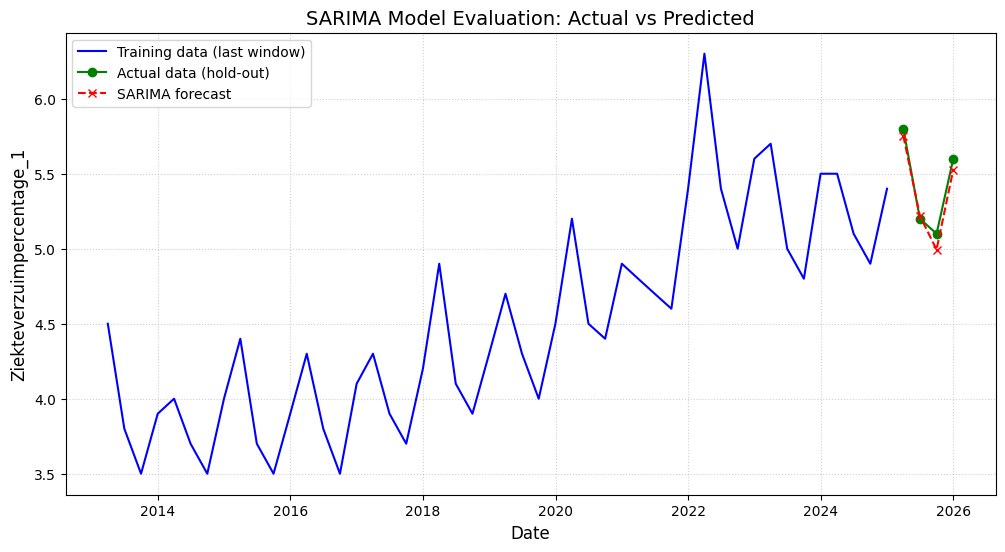

In [114]:
### STEP 7: Forecast and Calculate Metrics
print("\n--- STEP 7: Forecast and Calculate Metrics ---")

# Generate the definitive forecast for the hold-out period
final_forecast = final_model_fit.forecast(steps=HORIZON)

# Calculate the evaluation metrics (RMSE and MAE)
final_rmse = root_mean_squared_error(final_test_data[TARGET_COLUMN], final_forecast)
final_mae = mean_absolute_error(final_test_data[TARGET_COLUMN], final_forecast)

print(f"Final evaluation on the hold-out set (last {HORIZON} quarters):")
print(f"  -> RMSE (Root Mean Squared Error): {final_rmse:.2f}")
print(f"  -> MAE  (Mean Absolute Error):     {final_mae:.2f}\n")

# Show comparison table
df_comparison = pd.DataFrame({
    'Actual': final_test_data[TARGET_COLUMN].values,
    'Predicted': final_forecast.values
}, index=final_test_data.index)
print("Comparison table:")
print(df_comparison)

# Plot the training data, the actual test data and the forecast in a single graph
plt.figure(figsize=(12, 6))

# Training data (for visual context we show the last few years of the training window)
plt.plot(final_train_set.index, final_train_set[TARGET_COLUMN], label='Training data (last window)', color='blue')
# Actual test data
plt.plot(final_test_data.index, final_test_data[TARGET_COLUMN], label='Actual data (hold-out)', color='green', marker='o')
# Predicted data
plt.plot(final_test_data.index, final_forecast, label='SARIMA forecast', color='red', linestyle='--', marker='x')

plt.title('SARIMA Model Evaluation: Actual vs Predicted', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel(TARGET_COLUMN, fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Step 8: Finally compare the trained ARIMA model vs seasonal baseline model (06a_nb_ML_baseline_vs_naive_DESN.ipynb)

## The Shortcut: `auto_arima`

Once you understand the steps above, you can look into the `pmdarima` library. Its `auto_arima` function acts like a grid search that automatically tests various combinations of $(p, d, q)$ and selects the best one based on the lowest **AIC** (Akaike Information Criterion) score. However, doing it manually first will give you the intuition you need to spot when automated tools go wrong.

Which step of this plan feels the most daunting to you right now, or would you like to explore how to read an ACF/PACF plot next?